In [1]:
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
from glob import glob


# Load metadata

In [4]:
with zipfile.ZipFile("./output/retrieved_df/retrieved_df2.json.zip", "r") as z:
    for filename in z.namelist():
        with z.open(filename) as f:
            data = f.read()
            data = json.loads(data)


f.close()
z.close()
metadata_retrieved_df = pd.read_json(data, orient='index')
metadata_retrieved_df.pmid = metadata_retrieved_df.pmid.astype(str)
print(metadata_retrieved_df.columns)

Index(['pmid', 'pmcid', 'title', 'abstract', 'mesh', 'keywords', 'authors',
       'journal', 'pub_type', 'pub_date', 'doi', 'issn', 'crossref',
       'full_text_links', 'licenses', 'pdf', 'xml', 'html', 'plain', 'pmc_tgz',
       'xml_parse_d', 'html_parse_d', 'pdf_parse_d', 'plain_parse_d',
       'content_text'],
      dtype='object')


/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95593/368234517.py:10: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  metadata_retrieved_df = pd.read_json(data, orient='index')


In [6]:
metadata_retrieved_df.shape

(300, 25)

In [8]:
metadata_retrieved_df.head()

,pmid,pmcid,title,abstract,mesh,keywords,authors,journal,pub_type,pub_date,...,pdf,xml,html,plain,pmc_tgz,xml_parse_d,html_parse_d,pdf_parse_d,plain_parse_d,content_text
884644d359df46f59ed24980bcf60834,2232487,None,Role of enhanced glomerular synthesis of throm...,Normotensive rats of the Milan strain (MNS) sp...,"[Animals, Glomerulosclerosis, Focal Segmental/...",None,"[Salvati P, Ferti C, Ferrario RG, Lamberti E, ...",Kidney international,"[Journal Article, Research Support, Non-U.S. G...",1990-09-26,...,0,0,0,1,0,{},{},{},{'file_path': './output/formats/txts/884644d35...,1
a068866a075b434d9331a4951ba37ff5,2718779,None,Treatment of congenital osteopetrosis in the r...,Osteopetrosis is a congenital metabolic bone d...,"[Animals, Body Weight, Bone and Bones/diagnost...",None,"[Popoff SN, McGuire JL, Zerwekh JE, Marks SC Jr]",Journal of bone and mineral research : the off...,"[Journal Article, Research Support, Non-U.S. G...",1989-02-26,...,0,0,0,0,0,{},{},{},{},0
98e4bfa4011d408cabba6691b2f69023,6208337,None,DNA changes in spinal cords of rats with exper...,DNA levels were measured in the spinal cords o...,"[Animals, Aspartic Acid Endopeptidases, DNA/*m...",None,"[Smith ME, Somera FP, Saldivar R, Massacesi L,...",Journal of neurochemistry,"[Journal Article, Research Support, Non-U.S. G...",1984-12-26,...,0,0,0,0,0,{},{},{},{},0
4b5ebbd9fed2419786d2ce322dd65069,7593554,None,Additive effects of copolymer-1 and interferon...,Copolymer-1 (Cop-1) inhibits the T cell respon...,"[Antigen-Presenting Cells/immunology, Cell Lin...",None,"[Milo R, Panitch H]",Journal of neuroimmunology,"[Journal Article, Research Support, Non-U.S. G...",1995-09-26,...,0,0,0,1,0,{},{},{},{'file_path': './output/formats/txts/4b5ebbd9f...,1
58b8d364559a4dc48232aaabf8343768,7595604,None,Pharmacokinetics and tolerability of ventricul...,The discovery of mutations in the gene for Cu/...,[Amyotrophic Lateral Sclerosis/*drug therapy/g...,None,"[Smith RA, Balis FM, Ott KH, Elsberry DD, Sher...",Journal of the neurological sciences,"[Clinical Trial, Journal Article]",1995-05-26,...,0,0,0,1,0,{},{},{},{'file_path': './output/formats/txts/58b8d3645...,1


In [10]:
# Make sure these columns are numeric (coerce errors if needed)
cols_to_sum = ['pdf', 'xml', 'html', 'plain', 'content_text']
metadata_retrieved_df[cols_to_sum] = metadata_retrieved_df[cols_to_sum].apply(pd.to_numeric, errors='coerce')

# Calculate total sum of each column
total_sums = metadata_retrieved_df[cols_to_sum].sum()

# Print the result
print(total_sums)

pdf             121
xml              69
html             52
plain            84
content_text    216
dtype: int64


In [12]:
# Count how many of the 5 formats are available per row
metadata_retrieved_df['format_count'] = metadata_retrieved_df[['pdf', 'xml', 'html', 'plain']].sum(axis=1)

# Preview rows where more than 1 format is present
multi_format_df = metadata_retrieved_df[metadata_retrieved_df['format_count'] > 1]

print(f"Number of articles with multiple formats: {len(multi_format_df)}")
print(multi_format_df[['pmid', 'format_count'] + cols_to_sum].head())

Number of articles with multiple formats: 83
                                      pmid  format_count  pdf  xml  html  \
9cc236101265495b87a2507e0b56c527  11306603             2    1    0     1   
d3c258b675ff4563818cae9c6f8590b4  15557109             2    1    0     1   
8f1c69bcbf8a43ce9626a872db6d0b5e  16951693             2    1    0     1   
d25e9c25222a4ec3b40435beb8983fbb  17634127             3    1    1     1   
3d7cda8e7f2f4adfb7c988c0343c2203  17676050             2    1    0     1   

                                  plain  content_text  
9cc236101265495b87a2507e0b56c527      0             1  
d3c258b675ff4563818cae9c6f8590b4      0             1  
8f1c69bcbf8a43ce9626a872db6d0b5e      0             1  
d25e9c25222a4ec3b40435beb8983fbb      0             1  
3d7cda8e7f2f4adfb7c988c0343c2203      0             1  


In [14]:
only_plain_df = metadata_retrieved_df[
    (metadata_retrieved_df['plain'] == 1) &
    (metadata_retrieved_df[['pdf', 'xml', 'html']].sum(axis=1) == 0)
]

print(f"Number of articles with only 'plain' format: {len(only_plain_df)}")

Number of articles with only 'plain' format: 78


In [16]:
only_plain_df = metadata_retrieved_df[
    (metadata_retrieved_df['pdf'] == 1) &
    (metadata_retrieved_df[['plain', 'xml', 'html']].sum(axis=1) == 0)
]

print(f"Number of articles with only 'plain' format: {len(only_plain_df)}")

Number of articles with only 'plain' format: 38


In [23]:
zip_files = glob("output/formats/pdfs/*.zip")  # Replace with your actual path
print(f"Number of ZIP files: {len(zip_files)}")

Number of ZIP files: 121


### proportion with content over time

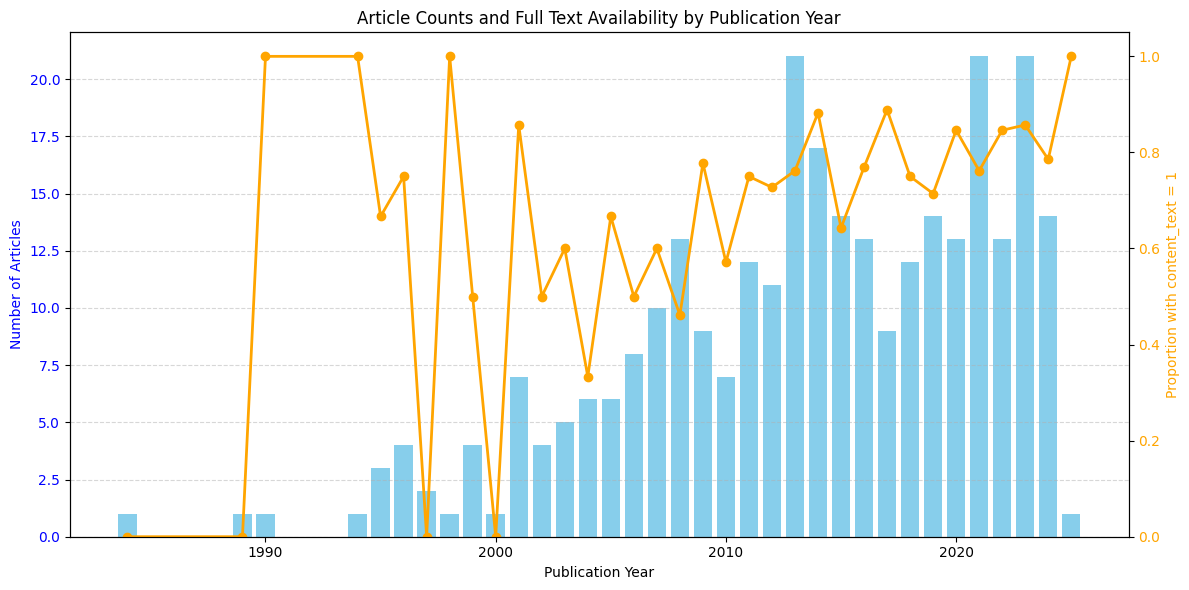

In [26]:
# Prep data
df = metadata_retrieved_df.copy()
df['pub_date'] = pd.to_datetime(df['pub_date'], errors='coerce')
df['pub_year'] = df['pub_date'].dt.year
df['content_text'] = pd.to_numeric(df['content_text'], errors='coerce')

grouped = df.groupby('pub_year')
year_distribution = grouped.size()
content_proportion = grouped['content_text'].mean()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart (article count)
bars = ax1.bar(year_distribution.index, year_distribution.values, color='skyblue', label='Article Count')
ax1.set_xlabel('Publication Year')
ax1.set_ylabel('Number of Articles', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart (proportion with content_text = 1)
ax2 = ax1.twinx()
line = ax2.plot(content_proportion.index, content_proportion.values, color='orange', marker='o', linewidth=2, label='Proportion with content_text = 1')
ax2.set_ylabel('Proportion with content_text = 1', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(0, 1.05)  # force full proportion scale for better visibility

# Title and layout
plt.title('Article Counts and Full Text Availability by Publication Year')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()


### count no content/journal

In [29]:
no_content_df = df[df['content_text'] == 0]
print(no_content_df.shape)
# Count PMIDs per journal (assuming 'PMID' and 'JT' columns exist)
pmid_counts_per_journal = no_content_df.groupby('journal')['pmid'].count().sort_values(ascending=False)

# Show the result
print(pmid_counts_per_journal.head(10))  # Top 10 journals

(84, 27)
journal
Journal of immunology (Baltimore, Md. : 1950)                                                            6
The Journal of neuroscience : the official journal of the Society for Neuroscience                       5
American journal of physiology. Renal physiology                                                         5
Xi bao yu fen zi mian yi xue za zhi = Chinese journal of cellular and molecular immunology               2
Biochemistry                                                                                             2
FASEB journal : official publication of the Federation of American Societies for Experimental Biology    2
Journal of neurochemistry                                                                                2
Journal of neuropathology and experimental neurology                                                     2
Proceedings of the National Academy of Sciences of the United States of America                          2
Brain : a journal of

## Load Medline

In [32]:

# Find all the zipped JSON files (adjust if needed)
zip_files = glob("output/medline/json/*.json.zip")
records = []

# Use a safe relative path for extraction
extract_root = "./temp_extracted"
os.makedirs(extract_root, exist_ok=True)

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_root)
        for file_name in zip_ref.namelist():
            json_path = os.path.join(extract_root, file_name)
            if json_path.endswith(".json") and os.path.isfile(json_path):
                with open(json_path, 'r') as f:
                    try:
                        data = json.load(f)
                        records.append(data)
                    except json.JSONDecodeError:
                        print(f"Failed to parse JSON: {json_path}")

# Convert to DataFrame
df = pd.json_normalize(records)

# Display DataFrame summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   PMID    300 non-null    object
 1   OWN     300 non-null    object
 2   STAT    300 non-null    object
 3   DCOM    284 non-null    object
 4   LR      300 non-null    object
 5   IS      299 non-null    object
 6   VI      299 non-null    object
 7   IP      236 non-null    object
 8   DP      300 non-null    object
 9   TI      300 non-null    object
 10  PG      288 non-null    object
 11  LID     226 non-null    object
 12  AB      300 non-null    object
 13  FAU     300 non-null    object
 14  AU      300 non-null    object
 15  AD      297 non-null    object
 16  LA      300 non-null    object
 17  PT      300 non-null    object
 18  DEP     195 non-null    object
 19  PL      300 non-null    object
 20  TA      300 non-null    object
 21  JT      300 non-null    object
 22  JID     300 non-null    ob

In [34]:
df.shape

(300, 54)

In [36]:
df.head()

,PMID,OWN,STAT,DCOM,LR,IS,VI,IP,DP,TI,...,COIS,CIN,RIN,EIN,SI,CON,ECI,TT,FIR,IR
0,20584752,NLM,MEDLINE,20110331,20220310,1755-3245 (Electronic) 0008-6363 (Linking),88,3,2010 Dec 1,OX40 ligand plays an important role in the dev...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8965116,NLM,MEDLINE,19961204,20190830,0340-5354 (Print) 0340-5354 (Linking),243,4 Suppl 1,1996 Apr,The autoimmune reactivity to myelin oligodendr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29607695,NLM,MEDLINE,20191028,20191028,2167-9223 (Electronic) 2167-8421 (Linking),19,7-8,2018 Nov,"""ALS reversals"": demographics, disease charact...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26522434,NLM,MEDLINE,20161007,20220129,1873-7064 (Electronic) 0028-3908 (Print) 0028-...,102,NaN,2016 Mar,Allosteric modulation of metabotropic glutamat...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19804131,NLM,PubMed-not-MEDLINE,20121002,20091006,1744-8298 (Electronic) 1479-6678 (Linking),2,1,2006 Jan,Towards a therapeutic use of selective CB2 can...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df[['JT', 'TA', 'PL']].head()


,JT,TA,PL
0,Cardiovascular research,Cardiovasc Res,England
1,Journal of neurology,J Neurol,Germany
2,Amyotrophic lateral sclerosis & frontotemporal...,Amyotroph Lateral Scler Frontotemporal Degener,England
3,Neuropharmacology,Neuropharmacology,England
4,Future cardiology,Future Cardiol,England


# Papermage

In [5]:
doc_path = "./output/formats/pdfs/0a5ab59cdc3d41b1a49e54a2fcf654fb.pdf"

In [4]:
from papermage.visualizers import plot_entities_on_page

In [5]:
from papermage.recipes import CoreRecipe

recipe = CoreRecipe()


/opt/anaconda3/envs/papermage/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/papermage/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/anaconda3/envs/papermage/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [35]:
doc = recipe.run(doc_path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:09<00:00,  1.85it/s]


In [36]:
doc.layers

['symbols',
 'images',
 'metadata',
 'tokens',
 'rows',
 'pages',
 'sentences',
 'blocks',
 'figures',
 'tables',
 'vila_entities',
 'titles',
 'paragraphs',
 'authors',
 'abstracts',
 'keywords',
 'sections',
 'lists',
 'bibliographies',
 'equations',
 'algorithms',
 'captions',
 'headers',
 'footers',
 'footnotes']

In [37]:
doc.sections

Layer with 27 Entities:
	Annotated Entity:	ID: 0	Spans: True	Boxes: True	Text: INTRODUCTION
	Annotated Entity:	ID: 1	Spans: True	Boxes: True	Text: MATERIALS AND METHODS Animals and TMEV Infection
	Annotated Entity:	ID: 2	Spans: True	Boxes: True	Text: Treatments
	Annotated Entity:	ID: 3	Spans: True	Boxes: True	Text: Evaluation of Motor Function
	Annotated Entity:	ID: 4	Spans: True	Boxes: True	Text: Sample Collection
	Annotated Entity:	ID: 5	Spans: True	Boxes: True	Text: Metabolite Analysis
	Annotated Entity:	ID: 6	Spans: True	Boxes: True	Text: CD4 T Cells ex vivo Experiments
	Annotated Entity:	ID: 7	Spans: True	Boxes: True	Text: ELISA
	Annotated Entity:	ID: 8	Spans: True	Boxes: True	Text: Tissue Processing and Immunohistochemistry
	Annotated Entity:	ID: 9	Spans: True	Boxes: True	Text: RNA Extraction, Reverse Transcription, and RT-PCR
	Annotated Entity:	ID: 10	Spans: True	Boxes: True	Text: Flow Cytometry
	Annotated Entity:	ID: 11	Spans: True	Boxes: True	Text: 16S rRNA Microbial Community

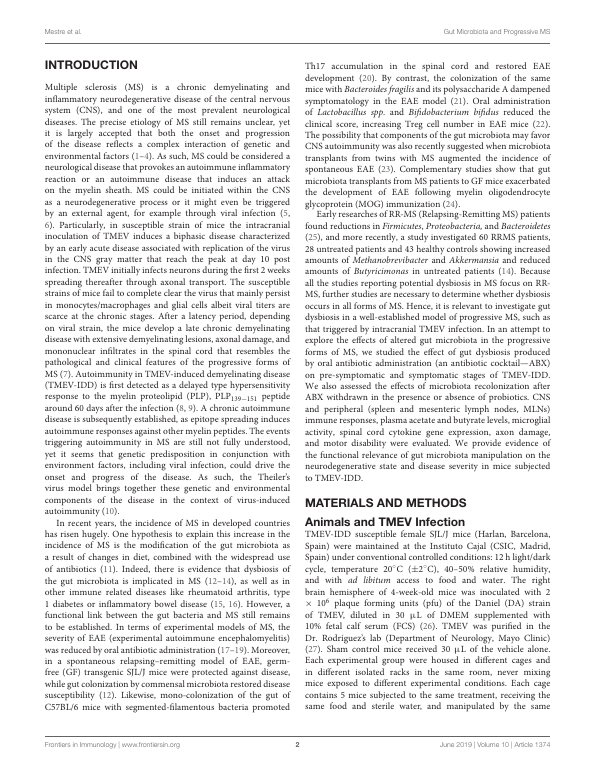

In [40]:
doc.pages[1].images[0]


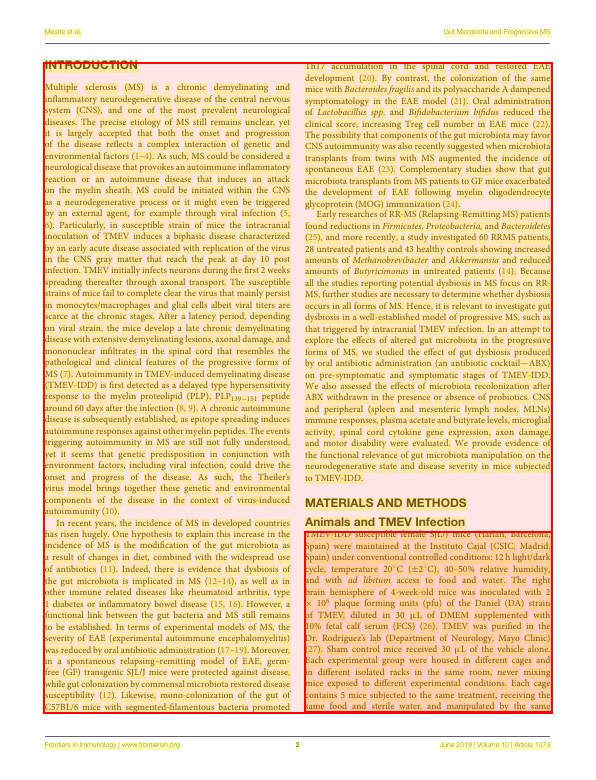

In [59]:
page = doc.pages[1]
highlighted = plot_entities_on_page(page.images[0], page.tokens, box_width=0, box_alpha=0.3, box_color="yellow")
highlighted = plot_entities_on_page(highlighted, page.paragraphs, box_width=2, box_alpha=0.1, box_color="red")
display(highlighted)

In [3]:
for section in doc.paragraphs:
    print(section)
    print()
  

NameError: name 'doc' is not defined

# Langchain

In [3]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_unstructured import UnstructuredLoader


In [22]:
loader = PyPDFLoader(doc_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)

In [24]:
pages[0]

Document(metadata={'producer': 'dvips + MiKTeX GPL Ghostscript  9.0', 'creator': 'LaTeX with hyperref package + hypdvips', 'creationdate': '2019-06-14T12:48:48+05:30', 'subject': 'Gut microbiota dysbiosis has been implicated in MS and other immune diseases, although it remains unclear how manipulating the gut microbiota may affect the disease course.', 'author': 'Leyre Mestre and Carmen Guaza', 'keywords': "Theiler's virus model, gut microbiota, Treg and Breg cells, neuroinflammation, multiple sclerosis", 'moddate': '2019-06-14T12:51:55+05:30', 'title': 'Manipulation of Gut Microbiota Influences Immune Responses, Axon Preservation, and Motor Disability in a Model of Progressive Multiple Sclerosis', 'source': './output/formats/pdfs/0a5ab59cdc3d41b1a49e54a2fcf654fb.pdf', 'total_pages': 18, 'page': 0, 'page_label': '1'}, page_content='ORIGINAL RESEARCH\npublished: 14 June 2019\ndoi: 10.3389/ﬁmmu.2019.01374\nFrontiers in Immunology | www.frontiersin.org 1 June 2019 | Volume 10 | Article 13

In [23]:
materials_and_methods = []
capture = False

# Loop through each page's content
for page in pages:
    text = page.page_content
    #print(text)
    # Check for the start of the section
    if "Materials and Methods" in text:
        capture = True
    if capture:
        materials_and_methods.append(text)
        # Optionally, define an end condition if there's a specific end to the section
    # Example end condition:
    # if "References" in text:
    #     capture = False

# Combine the extracted section into a single string
materials_and_methods_text = "\n".join(materials_and_methods)

# Output or process the extracted text
print(materials_and_methods_text)


In [16]:
materials_and_methods

[]

In [38]:
loader_local = UnstructuredLoader(
    file_path=doc_path,
    strategy="hi_res",
)
docs_local = []
for doc in loader_local.lazy_load():
    docs_local.append(doc)

INFO: Reading PDF for file: ./output/formats/pdfs/0a5ab59cdc3d41b1a49e54a2fcf654fb.pdf ...


In [9]:
len(docs_local)

312

In [13]:
docs_local[0].metadata.keys()
# docs_local[0].metadata['

dict_keys(['source', 'detection_class_prob', 'coordinates', 'last_modified', 'filetype', 'languages', 'page_number', 'file_directory', 'filename', 'category', 'element_id'])

In [33]:
docs_local[3].metadata['category']

'NarrativeText'

In [35]:
docs_local[2].page_content

'Edited by:'

In [54]:
from collections import Counter

texts_by_page = {}
for doc in docs_local:
    page = doc.metadata.get("page_number")
    text = doc.page_content.strip()
    if page is not None:
        texts_by_page.setdefault(page, []).append(text)

all_texts = [t for texts in texts_by_page.values() for t in texts]
counter = Counter(all_texts)

# Headers/footers usually appear many times
for text, count in counter.items():
    if count > 5:
        print(f"[x{count}] {text}")


[x18] Frontiers in Immunology | www.frontiersin.org
[x18] June 2019 | Volume 10 | Article 1374
[x17] Mestre et al.
[x17] Gut Microbiota and Progressive MS


In [56]:
# 1. Build a list of frequently repeated lines (potential headers/footers)
counter = Counter([doc.page_content.strip() for doc in docs_local])
repeated_lines = {text for text, count in counter.items() if count > 5}

# 2. Modify your loop
material_methods_docs = []
save_subs_conent = False

for doc in docs_local:
    text = doc.page_content.strip()
    
    # Skip headers/footers
    if text in repeated_lines:
        continue

    if doc.metadata["category"] == "Title" and "MATERIALS AND METHODS" in text.upper():
        save_subs_conent = True
        parent_id = doc.metadata.get("parent_id")
        print(f"Title {text}, ele id: {doc.metadata['element_id']}, parent: {parent_id}")
        if parent_id and parent_id in element_map:
            parent_text = element_map[parent_id].page_content.strip()
            print("parent text ", parent_text)

    if save_subs_conent and doc.metadata["category"] == "Title":
        print(text) #, doc.metadata["coordinates"])

    if save_subs_conent and doc.metadata["category"] == "NarrativeText":
        material_methods_docs.append(doc)

    if doc.metadata["category"] == "Title" and ("RESULTS" in text.upper() or "DISCUSSION" in text.upper()):
        save_subs_conent = False

# Output collected text
print("\nCollected content")
for doc in material_methods_docs:
    print(doc.page_content)

Title MATERIALS AND METHODS, ele id: 304aa4e303ea9869da9e156473c149b9, parent: 6327f927c5f82bcfdd14868668c5541e
parent text  Gut Microbiota and Progressive MS
MATERIALS AND METHODS
Animals and TMEV Infection
Treatments
Evaluation of Motor Function
Sample Collection
Metabolite Analysis
CD4T Cells ex vivo Experiments
ELISA
Tissue Processing and Immunohistochemistry
RNA Extraction, Reverse Transcription, and RT-PCR
Flow Cytometry
16S rRNA Microbial Community Analysis
Metagenome Functional Prediction
Statistical Analysis
RESULTS

Collected content
TMEV-IDD susceptible female SJL/J mice (Harlan, Barcelona, Spain) were maintained at the Instituto Cajal (CSIC, Madrid, Spain) under conventional controlled conditions: 12h light/dark cycle, temperature 20◦C (±2◦C), 40–50% relative humidity, and with ad libitum access to food and water. The right brain hemisphere of 4-week-old mice was inoculated with 2 × 106 plaque forming units (pfu) of the Daniel (DA) strain of TMEV, diluted in 30 µL of DMEM s

In [16]:
from langchain_community.retrievers import ArxivRetriever

retriever = ArxivRetriever(
    load_max_docs=2,
    get_ful_documents=True,
)

In [15]:
%pip install arxiv

  Preparing metadata (setup.py) ... done
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6089 sha256=9dfae885e9e5a0ec18f09fe41f89836e41cd59384c120e68b8c4f4fc68b24d78
  Stored in directory: /Users/sdoneva/Library/Caches/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built sgmllib3k
Note: you may need to restart the kernel to use updated packages.


In [17]:
docs = retriever.invoke("1605.08386")

INFO: Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=&id_list=1605.08386&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO: Got first page: 1 of 1 total results


In [21]:
print(docs[0].page_content)

Graphs on lattice points are studied whose edges come from a finite set of
allowed moves of arbitrary length. We show that the diameter of these graphs on
fibers of a fixed integer matrix can be bounded from above by a constant. We
then study the mixing behaviour of heat-bath random walks on these graphs. We
also state explicit conditions on the set of moves so that the heat-bath random
walk, a generalization of the Glauber dynamics, is an expander in fixed
dimension.
